In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
import sklearn
from sklearn.model_selection import train_test_split
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import BinaryCrossentropy
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import StratifiedGroupKFold

2026-03-28 14:01:09.296016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774706469.708361      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774706469.822078      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774706470.809621      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706470.809669      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774706470.809672      24 computation_placer.cc:177] computation placer alr

In [2]:
base_path = '/kaggle/input/datasets/abhijithc/covid-pneumonia-lus-images/covid_pneumonia'

In [3]:
for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        print(f"{cls}: {len(os.listdir(cls_path))}")

pneumonia: 463
covid: 524


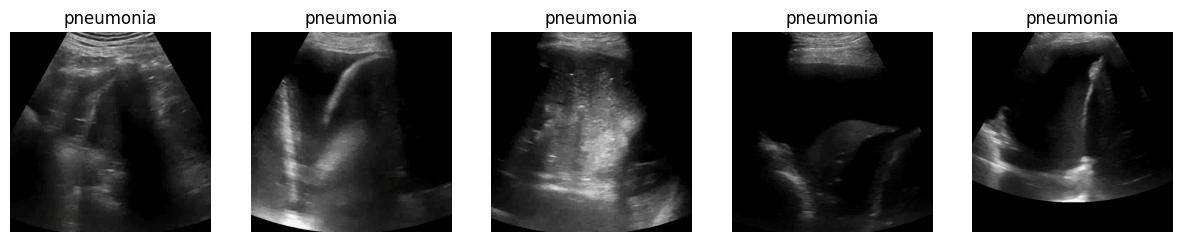

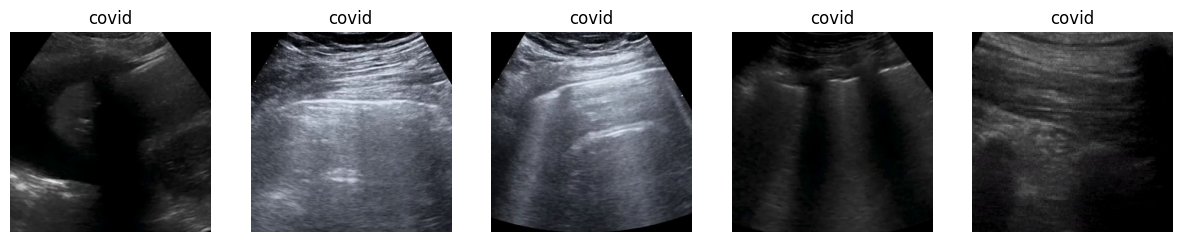

In [4]:
def show_samples(class_path, class_name, n=5):
    images = os.listdir(class_path)
    samples = random.sample(images, min(n, len(images)))

    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(samples):
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis('off')
    plt.show()

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if os.path.isdir(cls_path):
        show_samples(cls_path, cls)

In [5]:
image_paths = []
labels = []

for label in os.listdir(base_path):
    class_path = os.path.join(base_path, label)
    for img in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, img))
        labels.append(label)

df = pd.DataFrame({
    "filename": image_paths,
    "label": labels
})


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths, labels, test_size = 0.3, stratify=labels, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)


In [7]:
train_df = pd.DataFrame({
    "x": X_train,
    "y": y_train
}) 

val_df = pd.DataFrame({
    "x": X_val,
    "y": y_val
})

test_df = pd.DataFrame({
    "x": X_test,
    "y": y_test
})

In [8]:
train_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = train_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=True,
    seed=42
)

val_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = val_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

test_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_dataframe(
    dataframe = test_df,
    x_col="x",
    y_col="y",
    target_size=(224, 224),
    color_mode = "rgb",
    batch_size=32,
    class_mode="binary",
    shuffle=False,
)

Found 690 validated image filenames belonging to 2 classes.
Found 148 validated image filenames belonging to 2 classes.
Found 149 validated image filenames belonging to 2 classes.


In [9]:
images, labels = next(train_batches)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..112.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..143.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..101.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..89.061].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-123.68..108.061].


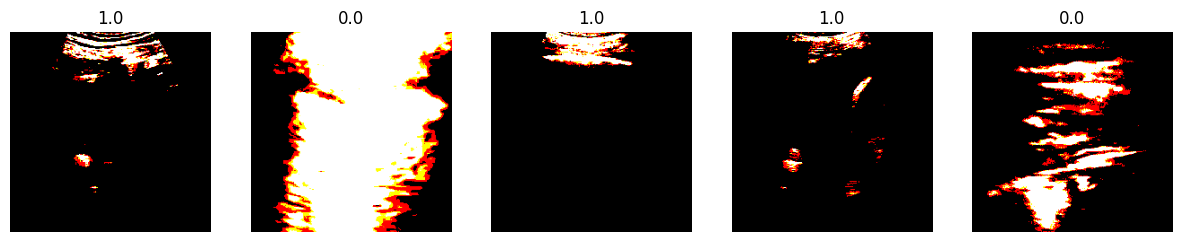

In [10]:
plt.figure(figsize=(15,5))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.show()

In [11]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu", input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2),
    Flatten(),
    Dense(units=1, activation="sigmoid")
])

I0000 00:00:1774706509.270180      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774706509.276091      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 200704)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │       200,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,097 (859.75 KB)

 Trainable params: 220,097 (859.75 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss="binary_crossentropy", metrics=["accuracy"])

In [14]:
model.fit(x=train_batches, validation_data=val_batches, epochs=10, verbose=2)

Epoch 1/10


I0000 00:00:1774706512.992663      73 service.cc:152] XLA service 0x7bbf48105880 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774706512.992702      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774706512.992706      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774706513.425899      73 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774706517.720054      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 - 16s - 710ms/step - accuracy: 0.6783 - loss: 11.6210 - val_accuracy: 0.8514 - val_loss: 3.0386
Epoch 2/10
22/22 - 4s - 159ms/step - accuracy: 0.8855 - loss: 1.5637 - val_accuracy: 0.9392 - val_loss: 0.6060
Epoch 3/10
22/22 - 4s - 162ms/step - accuracy: 0.9493 - loss: 0.2748 - val_accuracy: 0.9865 - val_loss: 0.4520
Epoch 4/10
22/22 - 4s - 161ms/step - accuracy: 0.9841 - loss: 0.0796 - val_accuracy: 0.9662 - val_loss: 0.2869
Epoch 5/10
22/22 - 4s - 166ms/step - accuracy: 0.9942 - loss: 0.0644 - val_accuracy: 0.9865 - val_loss: 0.2911
Epoch 6/10
22/22 - 3s - 156ms/step - accuracy: 0.9957 - loss: 0.0106 - val_accuracy: 0.9865 - val_loss: 0.1817
Epoch 7/10
22/22 - 4s - 160ms/step - accuracy: 0.9986 - loss: 0.0032 - val_accuracy: 0.9865 - val_loss: 0.2310
Epoch 8/10
22/22 - 4s - 164ms/step - accuracy: 0.9986 - loss: 0.0030 - val_accuracy: 0.9865 - val_loss: 0.1323
Epoch 9/10
22/22 - 4s - 165ms/step - accuracy: 1.0000 - loss: 3.1822e-04 - val_accuracy: 0.9865 - val_loss: 0.1492
Epoch 

In [15]:
from sklearn.metrics import confusion_matrix

y_pred = model.predict(test_batches)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(test_batches.classes, y_pred))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step
[[78  1]
 [ 0 70]]


In [16]:
test_loss, test_acc = model.evaluate(test_batches)
print(test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.9869 - loss: 0.1347
0.9932885766029358
